In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import numpy as np
import random

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

import sys
import os
import torch
from contextlib import redirect_stdout

# Assegurem que l'arrel del projecte està al path per carregar els mòduls
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from entrenament.entrenamentsUnificats.entrenaments_unificats import (
    init_dqn, init_nfsp, carregar_pesos, AgentCongelat, wrap_env_aplanat
)
from rlcard.agents import RandomAgent
from entorn import TrucEnv


# Comparativa d'Algorismes: DQN vs NFSP en el Joc del Truc

En aquest anàlisi comparem el rendiment del Deep Reinforcement Learning aplicat al joc de cartes del Truc, utilitzant dues arquitectures principals:

### 1. DQN (Deep Q-Network)
És un algorisme de Reinforcement Learning clàssic basat en la funció de valor.
*   **Funcionament:** L'agent aprèn una funció $Q$ que estima la recompensa futura de cada acció.
*   **Característica:** Està més enfocat a entorns amb un sol agent que aprèn o oponents fixos. En jocs d'estratègia canviant com el Truc, pot ser menys estable.

### 2. NFSP (Neural Fictitious Self-Play)
Algorisme dissenyat específicament per a jocs competitius de múltiples jugadors.
*   **Funcionament:** Combina el DQN amb l'aprenentatge supervisat a través del *Self-Play*. Manté una memòria per a l'exploració i una altra per aprendre la seva "estratègia mitjana".
*   **Característica:** És molt més robust en jocs d'**informació imperfecta** (on no veiem les cartes del rival), buscant apropar-se a un **Equilibri de Nash** i sent més difícil de preveure per l'adversari.

---
A continuació, analitzem l'evolució de l'entrenament i el rendiment final de cada estratègia (Scratch, Frozen i Fine-tune) per a ambdós algorismes.

In [ ]:
# Directori base de resultats
BASE_DIR = r"c:\Users\ferri\Documents\ProjectesCodi\TFG-truc\entrenament\entrenamentsUnificats\registres\resultats_comparativa"

# Experiments a carregar
experiments = {
    'DQN Scratch': 'dqn_scratch_0803_0209/logs/dqn_scratch.csv',
    'DQN Frozen': 'dqn_frozen_0703_2312/logs/dqn_frozen.csv',
    'DQN Fine-tune': 'dqn_finetune_0803_0024/logs/dqn_finetune.csv',
    'NFSP Scratch': 'nfsp_scratch_0703_1940/logs/nfsp_scratch.csv',
    'NFSP Frozen': 'nfsp_frozen_0703_1158/logs/nfsp_frozen.csv',
    'NFSP Fine-tune': 'nfsp_finetune_0703_1451/logs/nfsp_finetune.csv'
}

# Carregar dades
dfs = {}
for name, rel_path in experiments.items():
    path = os.path.join(BASE_DIR, rel_path.replace('/', os.sep))
    
    if os.path.exists(path):
        dfs[name] = pd.read_csv(path)
        print(f"Carregat {name}: {len(dfs[name])} registres.")
    else:
        print(f"Error: No s'ha trobat el fitxer per {name} a {path}")

# suavitzar corbes
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth


Carregat DQN Scratch: 100 registres.
Carregat DQN Frozen: 100 registres.
Carregat DQN Fine-tune: 100 registres.
Carregat NFSP Scratch: 100 registres.
Carregat NFSP Frozen: 100 registres.
Carregat NFSP Fine-tune: 100 registres.

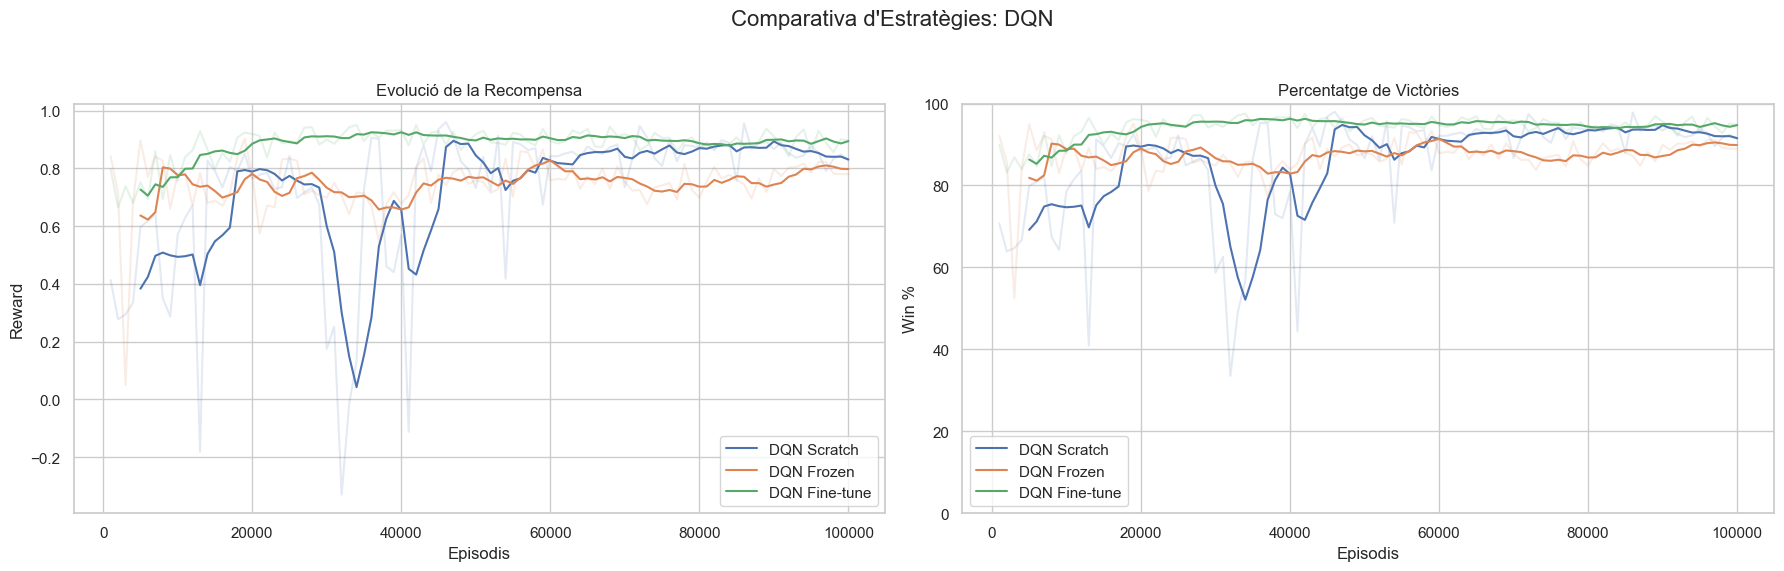

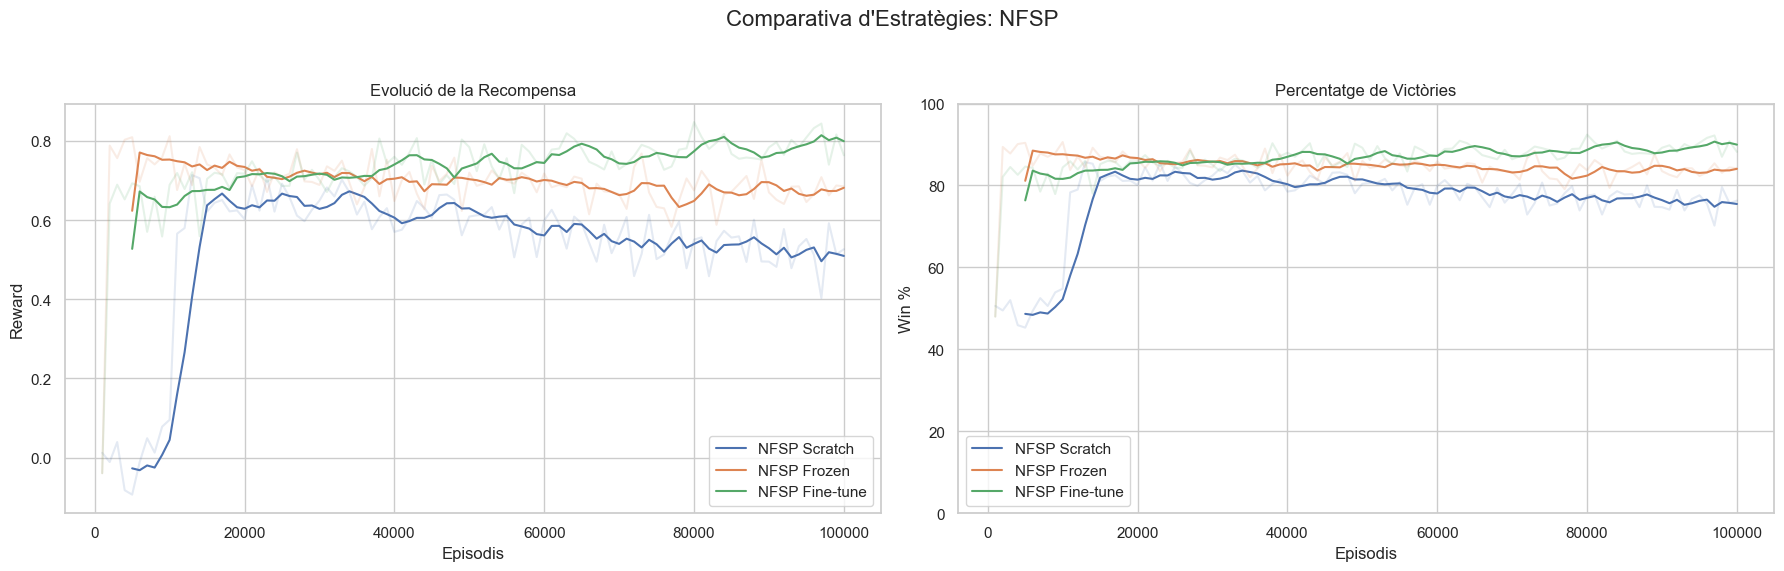

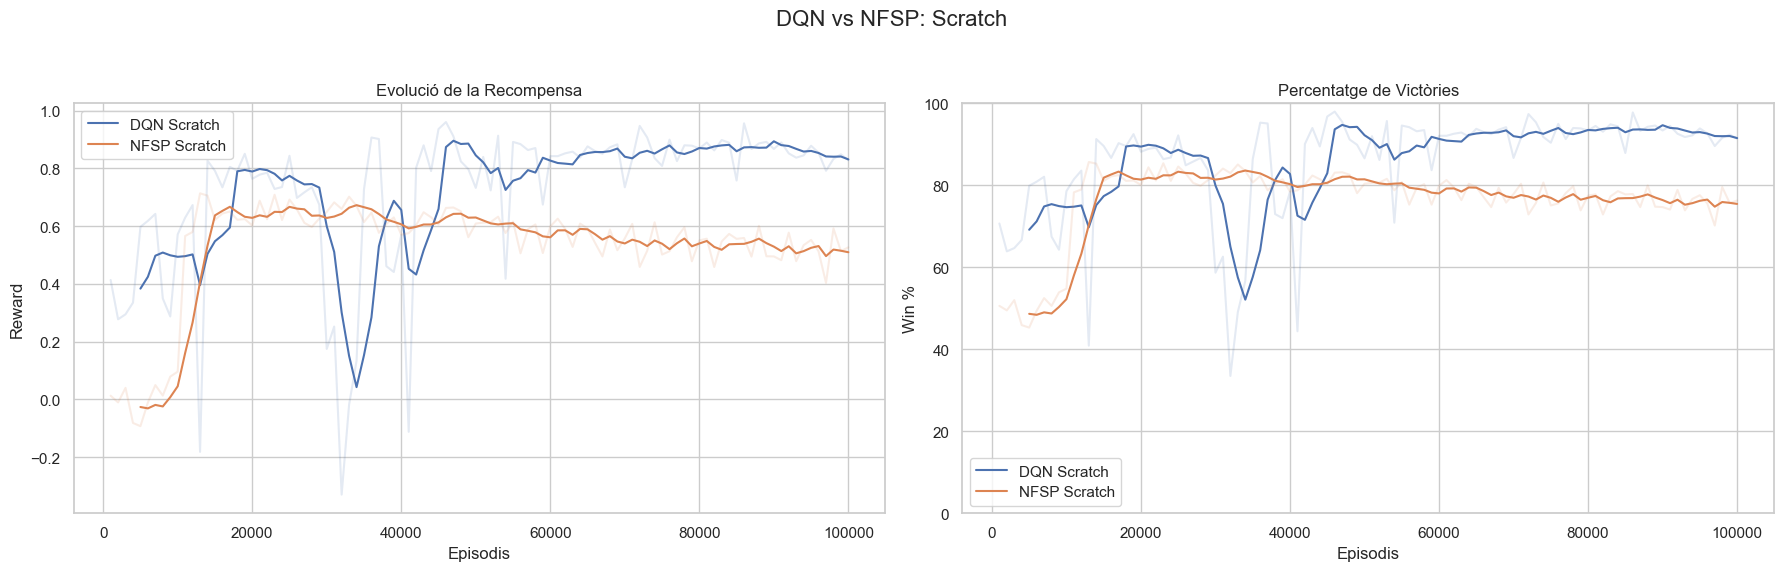

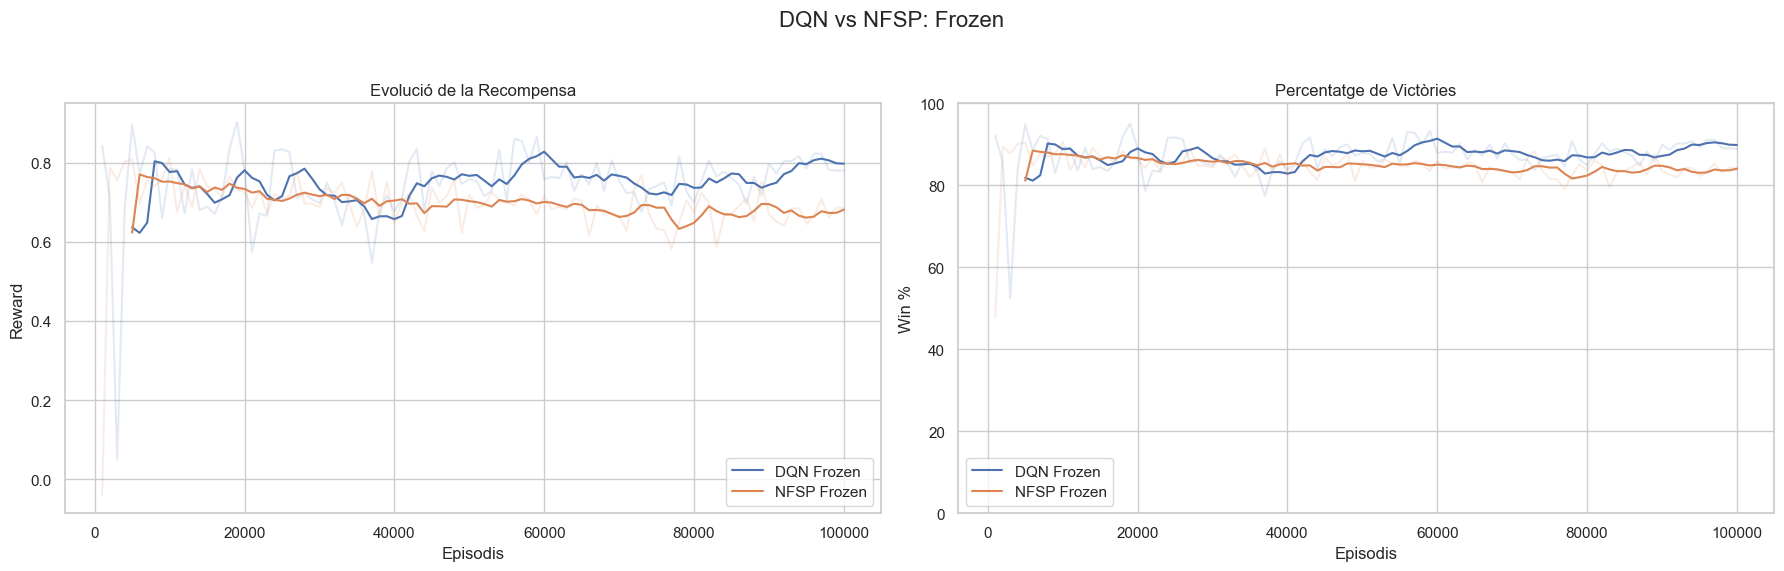

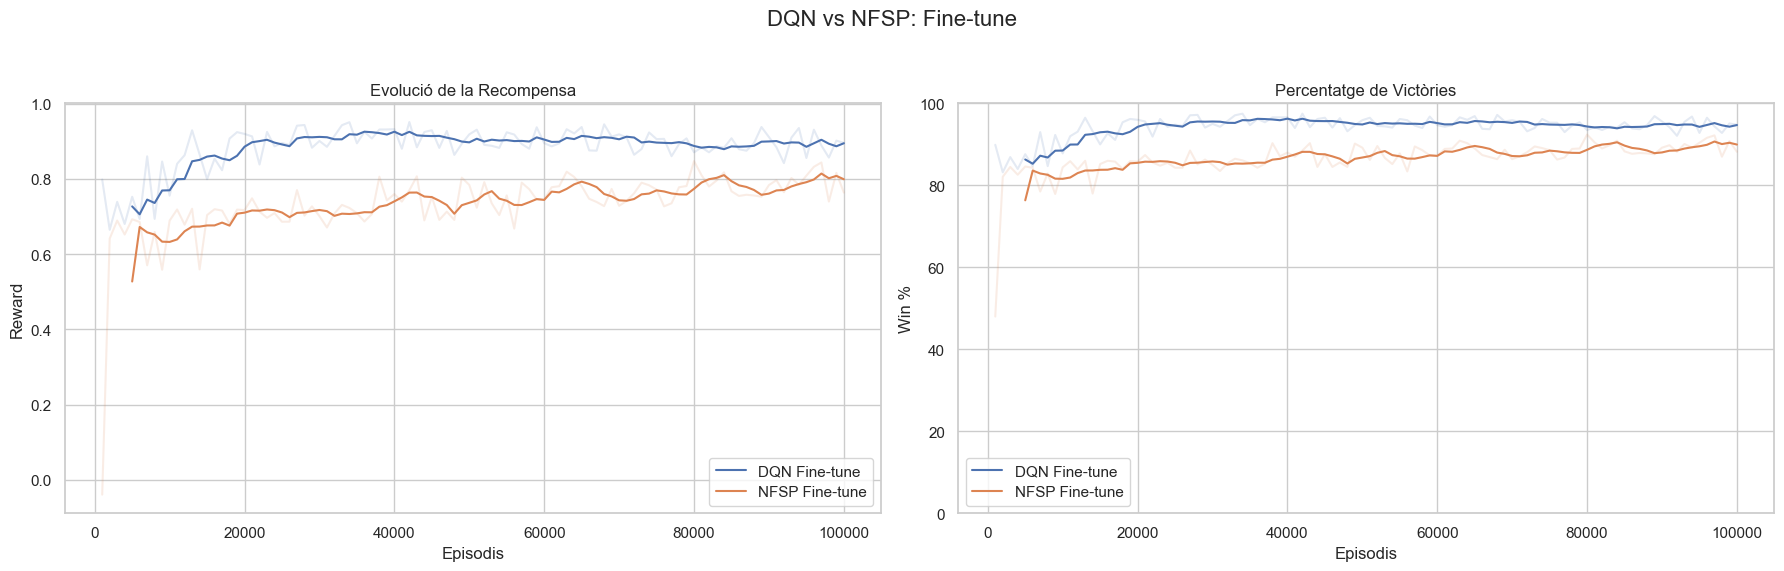

In [4]:
def plot_dual_comparison(dfs_dict, reward_map, winrate_map, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(title, fontsize=16)
    
    window = 5
    
    for name, df in dfs_dict.items():
        # Recompensa
        metric_r = reward_map.get('DQN' if 'DQN' in name else 'NFSP')
        if metric_r in df.columns:
            smoothed_r = df[metric_r].rolling(window=window).mean()
            line = ax1.plot(df['ep'], smoothed_r, label=f"{name}")
            ax1.plot(df['ep'], df[metric_r], alpha=0.15, color=line[0].get_color())
            
        # Win Rate
        metric_w = winrate_map.get('DQN' if 'DQN' in name else 'NFSP')
        if metric_w in df.columns:
            smoothed_w = df[metric_w].rolling(window=window).mean()
            line = ax2.plot(df['ep'], smoothed_w, label=f"{name}")
            ax2.plot(df['ep'], df[metric_w], alpha=0.15, color=line[0].get_color())
            
    ax1.set_title('Evolució de la Recompensa')
    ax1.set_xlabel('Episodis')
    ax1.set_ylabel('Reward')
    ax1.legend()
    
    ax2.set_title('Percentatge de Victòries')
    ax2.set_xlabel('Episodis')
    ax2.set_ylabel('Win %')
    ax2.set_ylim(0, 100)
    ax2.legend()
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

reward_map = {'DQN': 'reward', 'NFSP': 'r0'}
winrate_map = {'DQN': 'vic%', 'NFSP': 'vic0'}

# Comparativa DQN (Scratch vs Frozen vs Fine-tune)
dqn_dfs = {k: v for k, v in dfs.items() if 'DQN' in k}
plot_dual_comparison(dqn_dfs, reward_map, winrate_map, 'Comparativa d\'Estratègies: DQN')

# Comparativa NFSP (Scratch vs Frozen vs Fine-tune)
nfsp_dfs = {k: v for k, v in dfs.items() if 'NFSP' in k}
plot_dual_comparison(nfsp_dfs, reward_map, winrate_map, 'Comparativa d\'Estratègies: NFSP')

# Comparativa Directe DQN vs NFSP
for strategy in ['Scratch', 'Frozen', 'Fine-tune']:
    strategy_dfs = {k: v for k, v in dfs.items() if strategy in k}
    plot_dual_comparison(strategy_dfs, reward_map, winrate_map, f'DQN vs NFSP: {strategy}')

## 2. Lliga de Simulació de Partides

En aquest apartat s'enfronten tots els models carregats en una lliga (round-robin) per determinar quina estratègia i arquitectura ofereixen un millor rendiment en partides reals. Cada enfrontament consisteix en una sèrie de partides on els agents s'alternen per ser el primer jugador.

In [23]:
# Configuració Dispositiu
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Configuració Entorn per a simulació
ENV_CONFIG = {
    'num_jugadors': 2,
    'cartes_jugador': 3,
    'puntuacio_final': 12,
    'seed': 42,
    'verbose': False,
}
sim_env = wrap_env_aplanat(TrucEnv(ENV_CONFIG))

# Carregar tots els models
models_per_simular = {}
for name, rel_path in experiments.items():
    experiment_dir = rel_path.split('/')[0]
    
    # si no best.pt, si no best_p0.pt (per a NFSP)
    possibles_models = ['best.pt', 'best_p0.pt']
    model_path = None
    for m in possibles_models:
        path = os.path.join(BASE_DIR, experiment_dir, 'models', m)
        if os.path.exists(path):
            model_path = path
            break
    
    if model_path:
        mode_str = name.split(' ')[1].lower() if ' ' in name else 'scratch'
        if mode_str == 'fine-tune':
            mode_str = 'finetune'
            
        with redirect_stdout(open(os.devnull, 'w')):
            if 'DQN' in name:
                agent = init_dqn(sim_env, DEVICE, mode_str)
            else:
                agent = init_nfsp(sim_env, DEVICE, mode_str)
            
            carregar_pesos(agent, model_path, DEVICE)
            models_per_simular[name] = AgentCongelat(agent)
        print(f"{name} preparat per a la lliga (usant {os.path.basename(model_path)}).")
    else:
        print(f"Error: No s'ha trobat cap model .pt per a {name}")

# RandomAgent extra
models_per_simular['Random'] = RandomAgent(sim_env.num_actions)

DQN Scratch preparat per a la lliga (usant best.pt).
DQN Frozen preparat per a la lliga (usant best.pt).
DQN Fine-tune preparat per a la lliga (usant best.pt).
NFSP Scratch preparat per a la lliga (usant best_p0.pt).
NFSP Frozen preparat per a la lliga (usant best_p0.pt).
NFSP Fine-tune preparat per a la lliga (usant best_p0.pt).


In [26]:
# Paràmetres de la lliga
NUM_GAMES_MATCHUP = 1000
agents_list = list(models_per_simular.keys())
leaderboard_wins = {name: 0 for name in agents_list}
leaderboard_games = {name: 0 for name in agents_list}
enfrontaments = []

print(f"Iniciant lliga entre {len(agents_list)} agents ({NUM_GAMES_MATCHUP} partides/enfrontament)...")
random.shuffle(agents_list)

for i in range(len(agents_list)):
    for j in range(i + 1, len(agents_list)):
        nameA = agents_list[i]
        nameB = agents_list[j]
        agentA = models_per_simular[nameA]
        agentB = models_per_simular[nameB]
        
        winsA = 0
        winsB = 0
        
        # Enfrontament
        for g in range(NUM_GAMES_MATCHUP):
            # Alternar ordre
            p0, p1 = (agentA, agentB) if g % 2 == 0 else (agentB, agentA)
            sim_env.set_agents([p0, p1])
            
            # Executar partida
            state, player_id = sim_env.reset()
            while not sim_env.is_over():
                action = sim_env.agents[player_id].step(state)
                state, player_id = sim_env.step(action)
            
            payoffs = sim_env.get_payoffs()
            if g % 2 == 0:
                if payoffs[0] > 0: winsA += 1
                else: winsB += 1
            else:
                if payoffs[1] > 0: winsA += 1
                else: winsB += 1
        
        # Puntuació
        if winsA > winsB: leaderboard_wins[nameA] += 1
        elif winsB > winsA: leaderboard_wins[nameB] += 1
        else:
            leaderboard_wins[nameA] += 0.5
            leaderboard_wins[nameB] += 0.5
            
        leaderboard_games[nameA] += winsA
        leaderboard_games[nameB] += winsB
        print(f"Match: {nameA} vs {nameB} -> {round(winsA/NUM_GAMES_MATCHUP*100, 1)}-{round(winsB/NUM_GAMES_MATCHUP*100, 1)}")

print("\n--- LEADERBOARD FINAL ---")
sorted_leaderboard = sorted(leaderboard_wins.items(), key=lambda x: x[1], reverse=True)
for rank, (name, points) in enumerate(sorted_leaderboard, 1):
    print(f"{rank}. {name}: {points} punts (Total victòries: {leaderboard_games[name]})")

Iniciant lliga entre 7 agents (1000 partides/enfrontament)...
Match: DQN Frozen vs NFSP Scratch -> 54.4-45.6
Match: DQN Frozen vs DQN Scratch -> 43.4-56.6
Match: DQN Frozen vs Random -> 91.2-8.8
Match: DQN Frozen vs NFSP Fine-tune -> 37.5-62.5
Match: DQN Frozen vs DQN Fine-tune -> 25.0-75.0
Match: DQN Frozen vs NFSP Frozen -> 52.9-47.1
Match: NFSP Scratch vs DQN Scratch -> 35.9-64.1
Match: NFSP Scratch vs Random -> 79.7-20.3
Match: NFSP Scratch vs NFSP Fine-tune -> 29.4-70.6
Match: NFSP Scratch vs DQN Fine-tune -> 20.4-79.6
Match: NFSP Scratch vs NFSP Frozen -> 46.5-53.5
Match: DQN Scratch vs Random -> 94.6-5.4
Match: DQN Scratch vs NFSP Fine-tune -> 40.1-59.9
Match: DQN Scratch vs DQN Fine-tune -> 32.3-67.7
Match: DQN Scratch vs NFSP Frozen -> 56.8-43.2
Match: Random vs NFSP Fine-tune -> 11.2-88.8
Match: Random vs DQN Fine-tune -> 6.1-93.9
Match: Random vs NFSP Frozen -> 13.0-87.0
Match: NFSP Fine-tune vs DQN Fine-tune -> 39.1-60.9
Match: NFSP Fine-tune vs NFSP Frozen -> 67.9-32.1
Mat

## 3. Conclusions de la Comparativa

A partir dels gràfics d'entrenament i la lliga de simulació, podem observar:
- **Fine-tune**: Sol ser l'estratègia més eficient, arribant a nivells de recompensa alts més ràpidament gràcies a la transferència de coneixement de la Xarxa Unificada.
- **Frozen**: Ofereix una convergència molt ràpida inicialment, ja que només ha d'aprendre a interpretar les característiques ja extretes per la xarxa base.
- **Scratch**: Tot i que pot arribar a bels nivells, requereix més temps d'entrenament per aprendre tant la representació de l'estat com la política de joc.

A nivell d'arquitectura, **DQN** ha mostrat una major estabilitat en aquest entorn comparat amb **NFSP**, tot i que NFSP pot ser més robust en escenaris d'auto-aprenentatge pur.